In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# results (harcoded), generated from tad_disruption.ipynb
event_ba_sv_comparison = {
    'TP53_upstream' : [72.5, 44.2, 'p<0.001'],
    'MYC' : [57.9, 44.3, 'p<0.001'],
    'CCND3' : [66.1, 42.3, 'p<0.001'],
    'CCNE1' : [73.1, 57.3, 'p<0.01'],
    'CDK4-MDM2' : [64.8, 38.8, 'p<0.05']
}

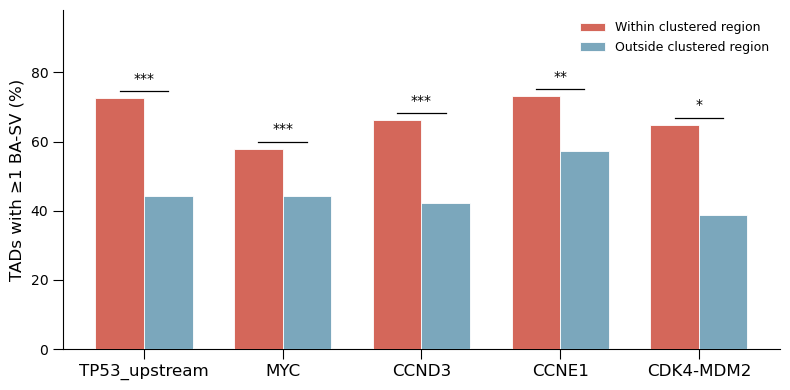

In [2]:
events    = list(event_ba_sv_comparison.keys())
clustered = [event_ba_sv_comparison[e][0] for e in events]
outside   = [event_ba_sv_comparison[e][1] for e in events]
pvals     = [event_ba_sv_comparison[e][2] for e in events]

def pval_to_stars(p_str):
    if p_str in ('p<0.001'):
        return '***'
    elif p_str == 'p<0.01':
        return '**'
    elif p_str == 'p<0.05':
        return '*'
    else:
        return 'ns'

x = np.arange(len(events))
width = 0.35

COL_CLUST   = '#D4675A'
COL_OUTSIDE = '#7BA7BC'
COL_EDGE    = 'white'

fig, ax = plt.subplots(figsize=(8, 4))

bars1 = ax.bar(x - width/2, clustered, width,
               label='Within clustered region',
               color=COL_CLUST, edgecolor=COL_EDGE, linewidth=0.6, zorder=3)
bars2 = ax.bar(x + width/2, outside, width,
               label='Outside clustered region',
               color=COL_OUTSIDE, edgecolor=COL_EDGE, linewidth=0.6, zorder=3)


def sig_bar(ax, x_left, x_right, y_top, stars,
            bar_gap=1.5, bar_height=1.2, tip_len=0.6, fontsize=10):

    y0    = y_top + bar_gap
    y1    = y0 + bar_height
    x_mid = (x_left + x_right) / 2

    # horizontal bar
    ax.plot([x_left, x_right], [y0 + tip_len, y0 + tip_len],
            color='black', lw=0.9, clip_on=False)
    # stars
    ax.text(x_mid, y1 + tip_len + 0.3, stars,
            ha='center', va='bottom',
            fontsize=fontsize, color='black')

for i, (c, o, p) in enumerate(zip(clustered, outside, pvals)):
    stars = pval_to_stars(p)
    sig_bar(ax,
            x_left=x[i] - width/2,
            x_right=x[i] + width/2,
            y_top=max(c, o),
            stars=stars)

ax.set_xticks(x)
ax.set_xticklabels(events, fontsize=12, color='black')
ax.set_ylabel('TADs with ≥1 BA-SV (%)', fontsize=12, color='black')
ax.set_ylim(0, 98)
ax.tick_params(axis='both', colors='black', length=7)

ax.legend(frameon=False, fontsize=9, loc='upper right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../results/combined_ba_sv_barplot.pdf', bbox_inches='tight', dpi=300)